<a href="https://colab.research.google.com/github/ShahSayem/Alzheimer-Disease-Detection/blob/main/Alzheimer_MobileNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
borhanitrash_alzheimer_mri_disease_classification_dataset_path = kagglehub.dataset_download('borhanitrash/alzheimer-mri-disease-classification-dataset')

print('Data source import complete.')


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.transforms import v2
import pandas as pd
import numpy as np
import cv2
from PIL import Image
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import tqdm

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device} device")

# Load and process dataset
BASE_DIR = "/kaggle/input/alzheimer-mri-disease-classification-dataset/Alzheimer MRI Disease Classification Dataset/Data/"
df = pd.read_parquet(f"{BASE_DIR}/train-00000-of-00001-c08a401c53fe5312.parquet", engine="pyarrow")
test = pd.read_parquet(f"{BASE_DIR}/test-00000-of-00001-44110b9df98c5585.parquet", engine="pyarrow")

Using cuda device


In [ ]:
def dict_to_image(image_dict):
    byte_string = image_dict['bytes']
    nparr = np.frombuffer(byte_string, np.uint8)
    return cv2.imdecode(nparr, cv2.IMREAD_GRAYSCALE)

df['img_arr'] = df['image'].apply(dict_to_image)
df.drop("image", axis=1, inplace=True)
test['img_arr'] = test['image'].apply(dict_to_image)
test.drop("image", axis=1, inplace=True)

N_CLASSES = df['label'].nunique()

In [ ]:
# Dataset class
class ImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        image = self.dataframe.iloc[idx]["img_arr"]
        label = self.dataframe.iloc[idx]["label"]
        image = Image.fromarray(image.astype(np.uint8))

        if self.transform:
            image = self.transform(image)
        if image.shape[0] == 1:
            image = image.repeat(3, 1, 1)

        return image, torch.tensor(label, dtype=torch.long)

In [ ]:
# Transforms
train_transforms = v2.Compose([
    v2.ToImage(),
    v2.Resize((224, 224)),
    v2.RandomHorizontalFlip(p=0.3),
    v2.RandomVerticalFlip(p=0.3),
    v2.RandomRotation(degrees=(-45, 45)),
    v2.GaussianBlur(kernel_size=3),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transforms = v2.Compose([
    v2.ToImage(),
    v2.Resize((224, 224)),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


In [ ]:
# Data loaders
batch_size = 32
train_loader = DataLoader(ImageDataset(df, train_transforms), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(ImageDataset(test, eval_transforms), batch_size=batch_size, shuffle=False)

In [ ]:
# MobileNet model
class MobileNetClassifier(nn.Module):
    def __init__(self, num_classes=N_CLASSES):
        super(MobileNetClassifier, self).__init__()
        self.base_model = models.mobilenet_v2(pretrained=True)
        for param in self.base_model.features.parameters():
            param.requires_grad = False
        self.base_model.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(self.base_model.last_channel, num_classes)
        )

    def forward(self, x):
        return self.base_model(x)

In [ ]:
# Training function
def train_model(model, loader, optimizer, num_epochs=10):
    model.train()
    criterion = nn.CrossEntropyLoss()
    train_losses = []

    for epoch in tqdm.tqdm(range(num_epochs)):
        running_loss = 0.0
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        train_losses.append(running_loss / len(loader))
    return model, train_losses

In [ ]:
# Prediction
def predict(model, dataloader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            preds.extend(predicted.cpu().numpy())
            trues.extend(labels.cpu().numpy())
    return preds, trues

In [ ]:
# Evaluation
def result_summary(preds, labels):
    acc = accuracy_score(labels, preds)
    print(f"Accuracy: {acc:.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(labels, preds))

In [ ]:
# Train model
model = MobileNetClassifier().to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.001)
model, train_losses = train_model(model, train_loader, optimizer, num_epochs=15)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth
100%|██████████| 13.6M/13.6M [00:00<00:00, 178MB/s]
100%|██████████| 15/15 [04:43<00:00, 18.88s/it]


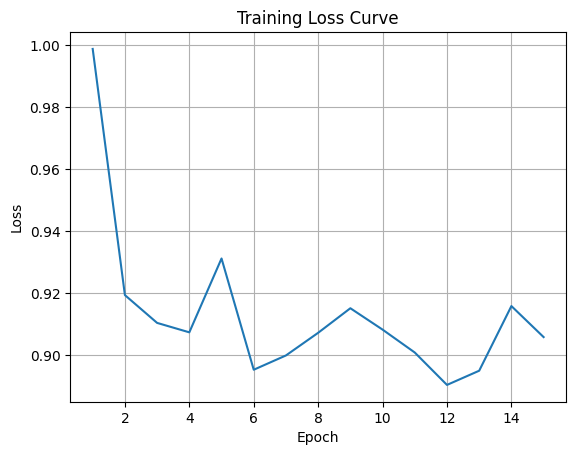

In [ ]:
# Plot training loss
plt.plot(range(1, len(train_losses) + 1), train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.grid()
plt.show()

In [ ]:
# Evaluate
train_preds, train_labels = predict(model, DataLoader(ImageDataset(df, eval_transforms), batch_size=batch_size))
test_preds, test_labels = predict(model, test_loader)

In [ ]:
print("Training Evaluation:")
result_summary(train_preds, train_labels)

print("\nTest Evaluation:")
result_summary(test_preds, test_labels)

Training Evaluation:
Accuracy: 0.6111
Confusion Matrix:
[[ 241    0  185  298]
 [  11    3   11   24]
 [ 116    0 2068  382]
 [ 183    0  781  817]]

Test Evaluation:
Accuracy: 0.5852
Confusion Matrix:
[[ 55   0  44  73]
 [  5   2   5   3]
 [ 37   0 492 105]
 [ 33   0 226 200]]
